In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import LearningRateScheduler

In [3]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 2  # Normal and Pneumonia

In [4]:
# Data Generators with Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Major_Project_Pneumonia_Detection/Dataset_2/train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 5276 images belonging to 2 classes.


In [6]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Major_Project_Pneumonia_Detection/Dataset_2/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [7]:
validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/Major_Project_Pneumonia_Detection/Dataset_2/val',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 16 images belonging to 2 classes.


In [8]:
from tensorflow.keras.layers import Dropout

# Load Pretrained DenseNet-169 Model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add Custom Layers for Classification
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)

x = Dropout(0.2)(x)
x = Dense(256, activation='relu')(x)

x = Dropout(0.2)(x)
x = Dense(128, activation='relu')(x)

x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)

predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

29084464/29084464 [==============================] - 0s 0us/step


In [9]:
# Compile the Model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Calculate steps_per_epoch and validation_steps
steps_per_epoch = len(train_generator)
validation_steps = len(validation_generator)

# Learning Rate Scheduler
def lr_schedule(epoch):
    initial_learning_rate = 0.0001
    decay = 0.9
    if epoch % 2 == 0:
        return initial_learning_rate * decay
    else:
        return initial_learning_rate

lr_callback = LearningRateScheduler(lr_schedule)

# Train the Model with Correct steps_per_epoch and validation_steps
model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=[lr_callback]
)

Epoch 1/10
165/165 [==============================] - 762s 4s/step - loss: 0.2824 - accuracy: 0.8734 - val_loss: 2.4013 - val_accuracy: 0.5000 - lr: 9.0000e-05
Epoch 2/10
165/165 [==============================] - 143s 865ms/step - loss: 0.1096 - accuracy: 0.9610 - val_loss: 2.5786 - val_accuracy: 0.5000 - lr: 1.0000e-04
Epoch 3/10
165/165 [==============================] - 139s 842ms/step - loss: 0.0924 - accuracy: 0.9674 - val_loss: 0.0255 - val_accuracy: 1.0000 - lr: 9.0000e-05
Epoch 4/10
165/165 [==============================] - 138s 837ms/step - loss: 0.0705 - accuracy: 0.9744 - val_loss: 0.0631 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 5/10
165/165 [==============================] - 139s 840ms/step - loss: 0.0583 - accuracy: 0.9788 - val_loss: 1.7296 - val_accuracy: 0.5625 - lr: 9.0000e-05
Epoch 6/10
165/165 [==============================] - 140s 847ms/step - loss: 0.0536 - accuracy: 0.9788 - val_loss: 1.6742 - val_accuracy: 0.6250 - lr: 1.0000e-04
Epoch 7/10
165/165 [=====

20/20 [==============================] - 8s 337ms/step - loss: 0.1715 - accuracy: 0.9423
Test Accuracy: 0.94
Test Loss: 0.17
20/20 [==============================] - 7s 351ms/step
Overall Accuracy: 0.94
Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.94      0.92       234
   Pneumonia       0.96      0.94      0.95       390

    accuracy                           0.94       624
   macro avg       0.94      0.94      0.94       624
weighted avg       0.94      0.94      0.94       624

Confusion Matrix:
[[220  14]
 [ 22 368]]


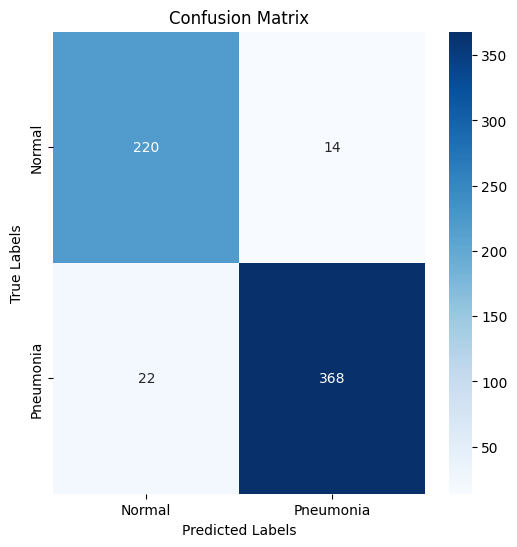

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Evaluate the model using the test generator
test_loss, test_accuracy = model.evaluate(test_generator, steps=len(test_generator))
print(f'Test Accuracy: {test_accuracy:.2f}')
print(f'Test Loss: {test_loss:.2f}')

# Predict using the model
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# True labels
true_labels = test_generator.classes

# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f'Overall Accuracy: {accuracy:.2f}')

# Generate and print classification report
report = classification_report(true_labels, predicted_labels, target_names=['Normal', 'Pneumonia'])
print(f'Classification Report:\n{report}')

# Generate and print confusion matrix
matrix = confusion_matrix(true_labels, predicted_labels)
print(f'Confusion Matrix:\n{matrix}')

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(matrix, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

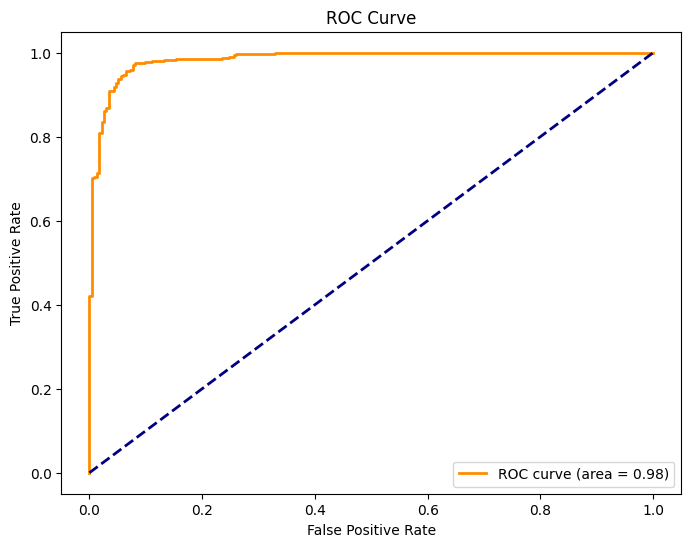

In [12]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(true_labels, predictions[:, 1])  # Assuming predictions[:, 1] gives probabilities for the positive class
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [13]:
# Save the Model
model.save('/content/drive/MyDrive/Major_Project_Pneumonia_Detection/models/pneumonia_model.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [14]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np

Enter the path to the image you want to classify: /content/drive/MyDrive/Major_Project_Pneumonia_Detection/Dataset_2/val/PNEUMONIA/person1947_bacteria_4876.jpeg
1/1 [==============================] - 3s 3s/step
The input image is classified as Pneumonia with confidence 80.13%.


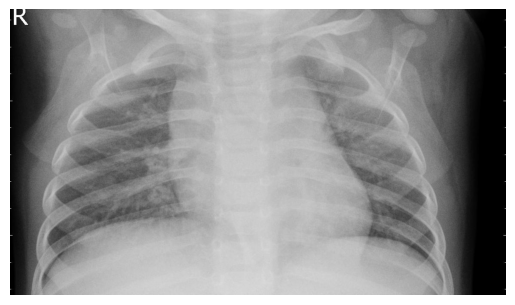

In [22]:
import matplotlib.pyplot as plt
# Load the pre-trained DenseNet-121 model
model = load_model('/content/drive/MyDrive/Major_Project_Pneumonia_Detection/models/pneumonia_model.h5')

# Function to preprocess the user input image
def preprocess_image(image_path):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize pixel values
    return img_array

# Take input image path from the user
input_image_path = input("Enter the path to the image you want to classify: ")

try:
    # Preprocess the input image
    input_img_array = preprocess_image(input_image_path)

    # Perform prediction
    predictions = model.predict(input_img_array)
    class_labels = ['Normal', 'Pneumonia']
    predicted_class_index = np.argmax(predictions)
    predicted_class = class_labels[predicted_class_index]
    confidence = predictions[0][predicted_class_index] * 100

    # Display the prediction
    print(f"The input image is classified as {predicted_class} with confidence {confidence:.2f}%.")

    # Display the image
    img = image.load_img(input_image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"Error: {e}")